## Проект по теме "Прогнозирование наличия сердечно-сосудистых заболеваний на основе характеристик пациентов"

Датасет представляет собой .csv файл, содержащий следующие поля:

* id: идентификатор для каждого человека в наборе данных;
* age: возраст человека (в днях);
* gender: пол (1 для женщин, 2 для мужчин);
* height: рост в сантиметрах;
* weight: вес в килограммах;
* ap_hi: систолическое артериальное давление (измеряется в мм рт.ст.);
* ap_lo: диастолическое артериальное давление (измеряется в мм рт.ст.);
* cholesterol: уровень холестерина (1 – в норме, 2 – выше нормы, 3 –
значительно выше нормы);
* gluc: уровень глюкозы (1 – в норме, 2 – выше нормы, 3 – значительно выше
нормы);
* smoke: курит ли человек (0 – нет, 1 – да);
* alco: употребляет ли человек алкоголь (0 – нет, 1 – да);
* active: является ли человек физически активным (0 – нет, 1 – да);
* cardio: наличие сердечно-сосудистых заболеваний (0 – нет, 1 – да).

Задачей является построить модель, предсказывающую наличие сердечно-сосудистых заболеваний.
Вам необходимо реализовать все дальнейшие шаги, обучить модель и оценить её качество.

## Задание 1: загрузка файла и проверка пропущенных значений (5 баллов)

Откройте данные и изучите их: есть ли пропущенные значения? Прокомментируйте результат. Если пропущенные значения есть - удалите строки с ними.

In [2]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации


from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки
from sklearn import ensemble #ансамблевые методы

# ваш код
cvd = pd.read_csv('/Users/konstantingeneralov/IDE/Data/cvd.csv', sep=';')
cvd_1 = cvd.copy()

#проверим наличие дубликатов
duplicate_rows = cvd_1.duplicated().sum()
print("Количество дубликатов в данных:", duplicate_rows)
# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": cvd_1.isnull().sum(),
    "unique": cvd_1.nunique(),
    "dtype": cvd_1.dtypes
})
display(summary)

display(cvd_1.head(), cvd_1.info(), cvd_1.describe())


Количество дубликатов в данных: 0


,missing,unique,dtype
id,0,70000,int64
age,0,8076,int64
gender,0,2,int64
height,0,109,int64
weight,0,287,float64
ap_hi,0,153,int64
ap_lo,0,157,int64
cholesterol,0,3,int64
gluc,0,3,int64
smoke,0,2,int64


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


None

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# выводы: 
# На анализ предоставлен датасет о сердечно-сосудистых заболеваниях (CVD), который содержит 11 признаков и 1 целевую переменную 'class'.
# Проведенный анализ показал, что в данных нет дубликатов и пропущенных значений, а также что целевая переменная 'class' имеет 2 уникальных значения,
# что указывает на задачу классификации.
# имеется столбец 'id', который не несет полезной информации для модели и может быть удален.
# Есть 7 категориальных признаков (gender, cholesterol, gluc, smoke, alco, active, cardio) и 5 числовых признака (age, height, weight, ap_hi, ap_lo), 
# что может потребовать различной предобработки перед обучением модели. 
# ap_hi ap_lo показывает артериальное давление, что может быть важным для предсказания сердечно-сосудистых заболеваний.
 

## Задание 2: проверка данных на мультиколлинеарность (15 баллов)

**2.1** Данные обязательно необходимо проверить на мультиколлинеарность: линейную взаимосвязь между признаками. Сначала проверим наличие чистой мультиколлинеарности. Для того, чтобы её идентифицировать - для начала посчитайте ранг для матрицы корреляций и ее определитель. Какой вывод можно сделать?

In [3]:
# Проверяем на мультиколлинеарность: линейную взаимосвязь между признаками. 
corr_matrix = cvd_1.corr()
rank = np.linalg.matrix_rank(corr_matrix)
det = np.linalg.det(corr_matrix)
print("Ранг матрицы корреляций:", rank)
print("Определитель матрицы корреляций:", det)

Ранг матрицы корреляций: 13
Определитель матрицы корреляций: 0.3467525937481181


In [ ]:
# Выводы:
# Ранг матрицы корреляций равен количеству признаков, что указывает на отсутствие линейной зависимости между ними.
# Определитель матрицы корреляций не равен нулю, что также подтверждает отсутствие мультиколлинеарности в данных.

**2.2** Теперь проверьте мультиколлинеарность с помощью матрицы корреляций. Какие выводы можно сделать?

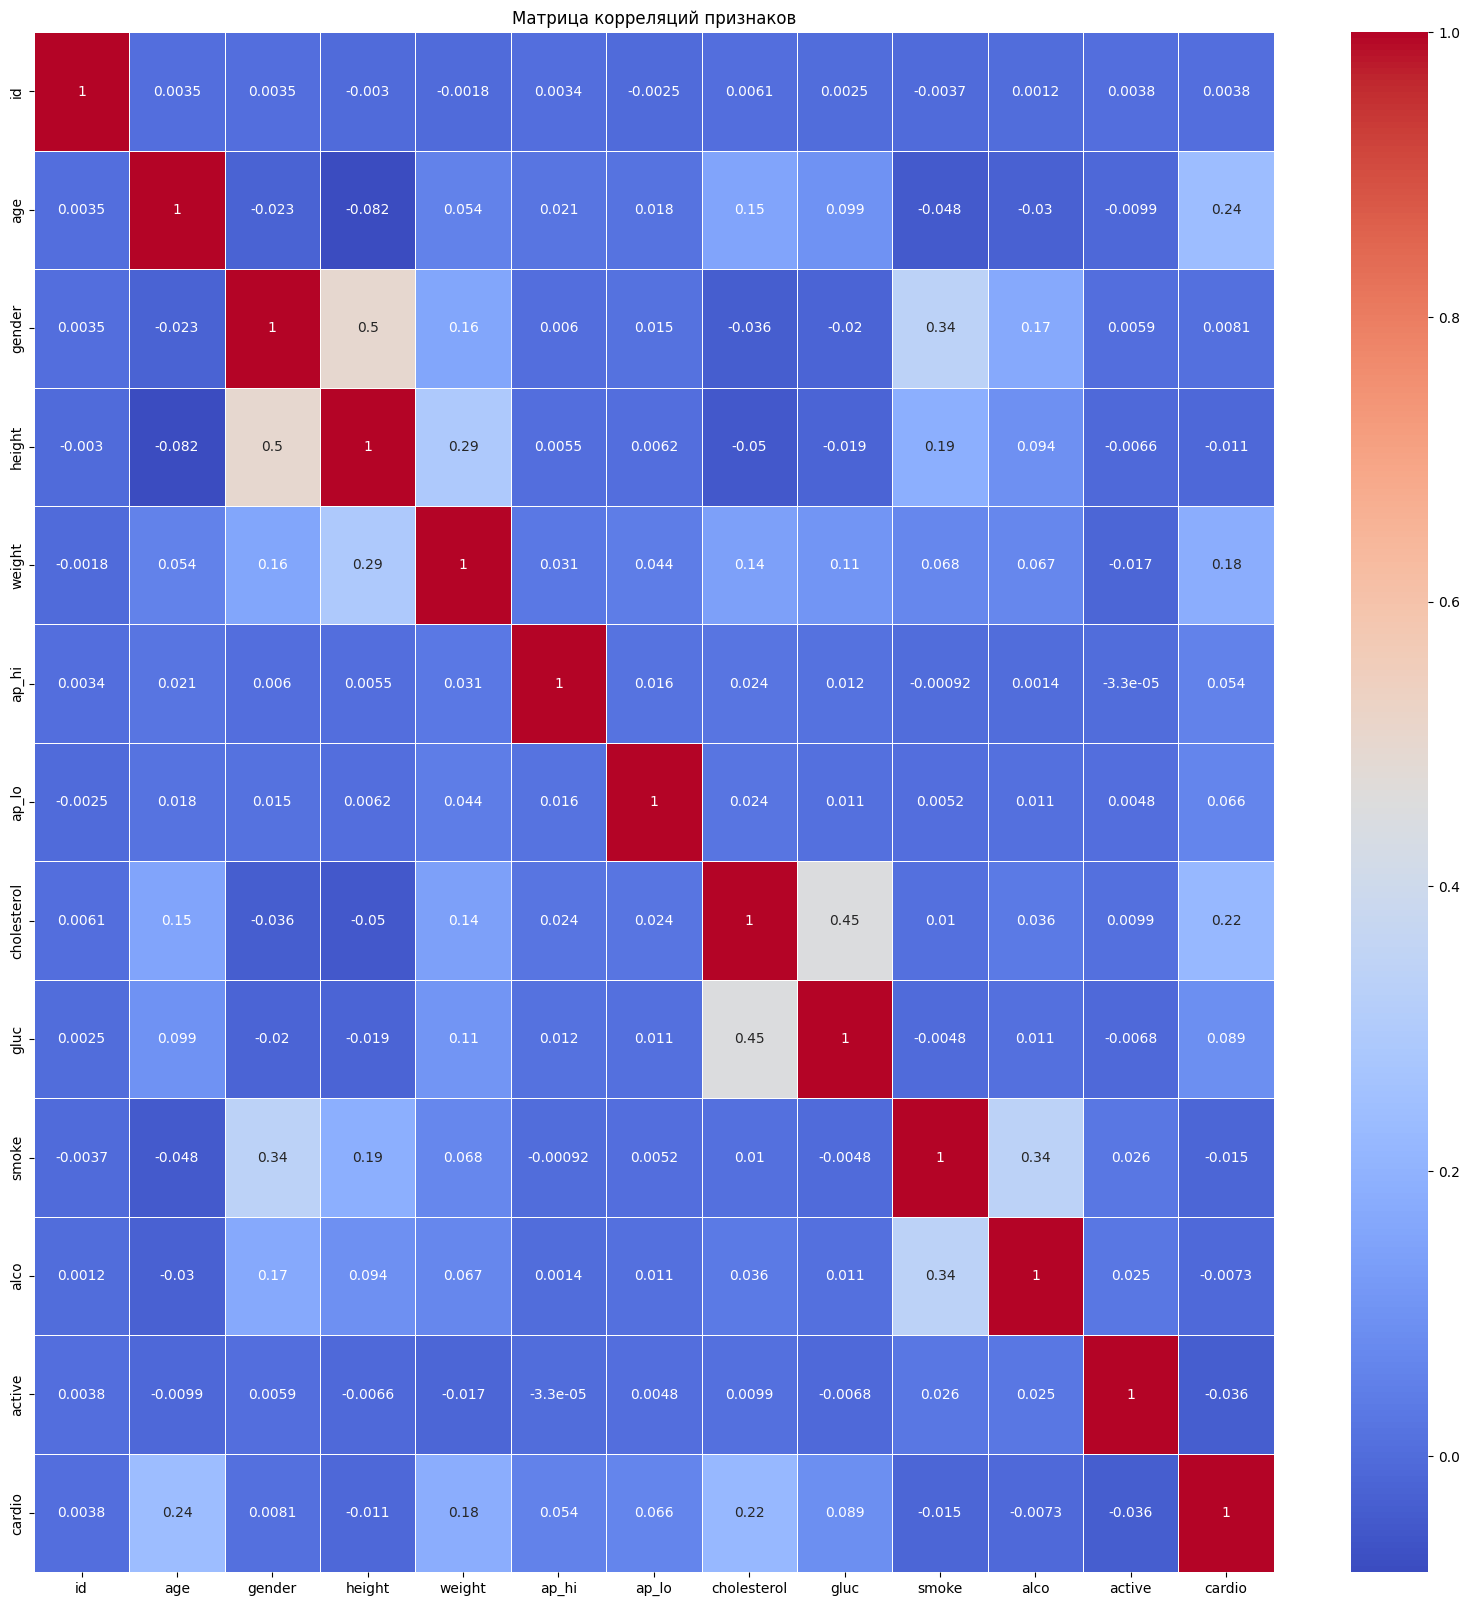

In [4]:
# Теперь проверьте мультиколлинеарность с помощью матрицы корреляций.
plt.figure(figsize=(20, 20))
sns.heatmap(cvd_1.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Матрица корреляций признаков')
plt.show()

In [ ]:
# выводы:
# по матрице корреляций видно, что нет сильной линейной зависимости между признаками, что подтверждает результаты проверки на мультиколлинеарность.
# больше всего коррелирует с целевой переменной 'cardio' (это наша целевая переменная) возраст 'age' 0.24 , уровень холестерина 'cholesterol' 0.22 и вес 'weight' 0.18,
# что может указывать на их важность для модели.

## Задание 3. Стандартизация (15 баллов)

Разделите данные на два массива: в переменную **Х** запишите массив признаков, а в переменную **y** - целевую переменную (cardio). Стандартизируйте массив признаков без использования готовых функций для стандартизации.

In [5]:
# Разделите данные на два массива: в переменную Х запишите массив признаков, а в переменную y- целевую переменную (cardio). 
# Стандартизируйте массив признаков без использования готовых функций для стандартизации.
X = cvd_1.drop(columns=['cardio'])
y = cvd_1['cardio']
X = (X - X.mean()) / X.std()


Вычислите длину всех векторов - признаков. Прокомментируйте результат.

In [7]:
# Вычислите длину всех векторов - признаков.
vector_lengths = np.linalg.norm(X, axis=1)
print("Длина векторов признаков:", vector_lengths)


Длина векторов признаков: [2.61422844 3.39932849 3.78102924 ... 6.51497399 3.37815632 2.37898692]


In [ ]:
# Вывод: длина векторных признаков
# 
 



## Задание 4. Решение задачи классификации. (20 баллов)

**4.1** Теперь приступим непосредственно к решению задачи классификации. Обучите наивный байесовский классификатор. Предварительно выберите один из его видов: поясните свой выбор.

In [ ]:
# ваш код

In [ ]:
# ваш комментарий

**4.2** Оцените полученное качество и проинтерпретируйте полученный результат. Не забудьте разделить выборку на обучающую и тестовую части.

In [ ]:
# ваш код

In [ ]:
# ваш комментарий

## Задание 5: Решающее дерево (25 баллов)

Теперь решите задачу классификации с помощью обучающего дерева.

**5.1** Обучите дерево, не задавая никакие гиперпараметры. Выведите получившиеся гиперпараметры. Какое получилось качество? Сравните результат с предыдущей моделью.

In [ ]:
# ваш код

In [ ]:
# ваш комментарий

**5.2** Подберите оптимальные гиперпараметры с помощью перебора по сетке. Обучите дерево с оптимальными гиперпараметрами. Изменилось ли качество?

In [ ]:
# ваш код

In [ ]:
# ваш комментарий

**5.3** Выведите важность признаков. Какие три признака самые важные? Прокомментируйте результат.

In [ ]:
# ваш код

In [ ]:
# ваш комментарий

## Задание 6: Случайный лес и градиентный бустинг (20 баллов)

Осталось применить ансамблевые методы!

**6.1** Используйте случайный лес: без настройки и с подробом гиперпараметров по сетке. Какое качество получается в ситуации оптимальных гиперпараметров? Какие признаки самые важные? Сравнение результат с простым решающим деревом.

In [ ]:
# ваш код

In [ ]:
# ваш комментарий

**6.2** Аналогичные операции реализуйте для градиентного бустинга. Попробуйте хотя бы две разных реализации градиентного бустинга. Сравните итоговое качество со случайным деревом.

In [ ]:
# ваш код

In [ ]:
# ваш комментарий